In [2]:
import pandas as pd
print("Setup working!")

Setup working!


In [3]:
train = pd.read_csv('../data/train.csv')
stores = pd.read_csv('../data/stores.csv')
oil = pd.read_csv('../data/oil.csv')
holidays = pd.read_csv('../data/holidays_events.csv')

print(train.shape)
train.head()

(3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])

train = train.merge(stores, on='store_nbr', how='left')
train = train.merge(oil, on='date', how='left')

train.isnull().sum()

id                  0
date                0
store_nbr           0
family              0
sales               0
onpromotion         0
city                0
state               0
type                0
cluster             0
dcoilwtico     928422
dtype: int64

In [7]:
train['dcoilwtico'] = train['dcoilwtico'].ffill()
train['dcoilwtico'] = train['dcoilwtico'].bfill()
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dcoilwtico     0
dtype: int64

In [8]:
train.to_csv('../data/cleaned_sales.csv', index=False)
print("Saved!")

Saved!


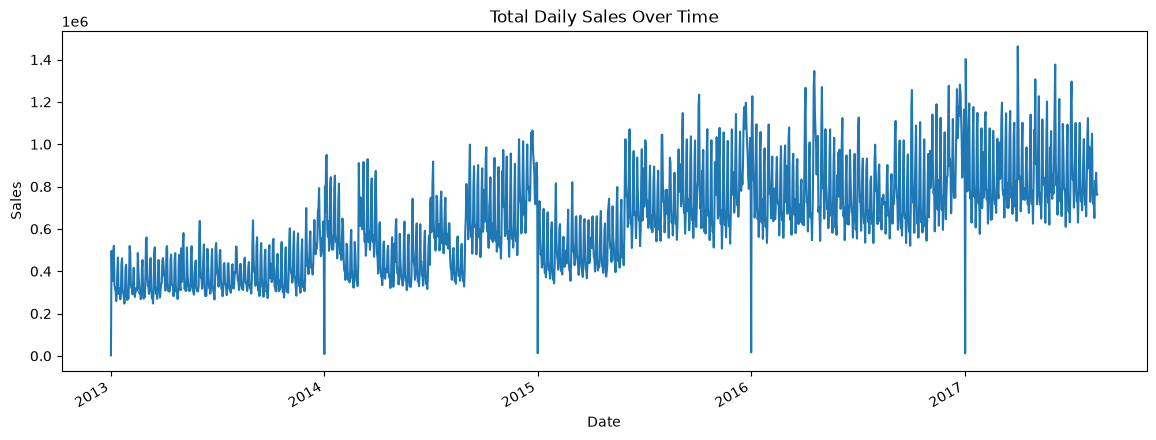

In [9]:
import matplotlib.pyplot as plt

daily_sales = train.groupby('date')['sales'].sum()

plt.figure(figsize=(14,5))
daily_sales.plot()
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.savefig('trend_chart.png')
plt.show()

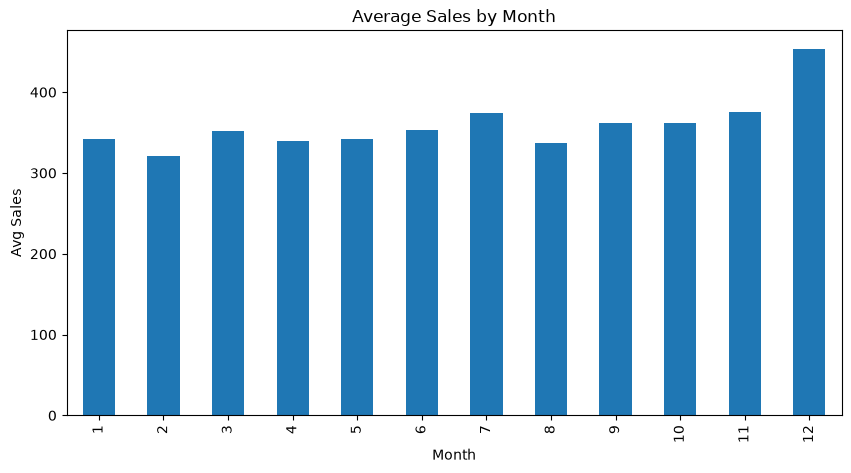

In [10]:
train['month'] = train['date'].dt.month
monthly_avg = train.groupby('month')['sales'].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(kind='bar')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Sales')
plt.savefig('monthly_seasonality.png')
plt.show()

<Figure size 1000x500 with 0 Axes>

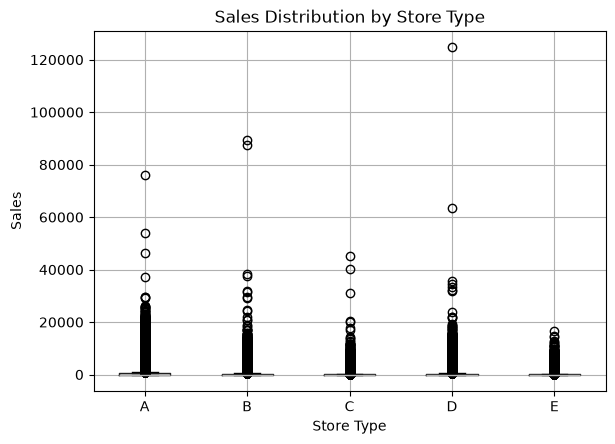

In [11]:
plt.figure(figsize=(10,5))
train.boxplot(column='sales', by='type')
plt.title('Sales Distribution by Store Type')
plt.suptitle('')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.savefig('store_type_sales.png')
plt.show()

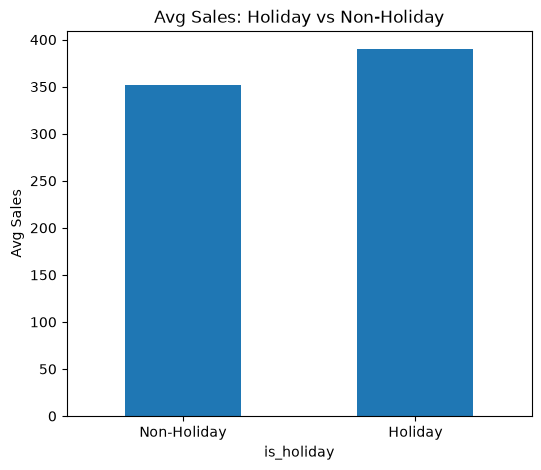

In [12]:
holidays['date'] = pd.to_datetime(holidays['date'])
holiday_dates = holidays['date'].unique()

train['is_holiday'] = train['date'].isin(holiday_dates).astype(int)
holiday_avg = train.groupby('is_holiday')['sales'].mean()

plt.figure(figsize=(6,5))
holiday_avg.plot(kind='bar')
plt.title('Avg Sales: Holiday vs Non-Holiday')
plt.xticks([0,1], ['Non-Holiday','Holiday'], rotation=0)
plt.ylabel('Avg Sales')
plt.savefig('holiday_impact.png')
plt.show()

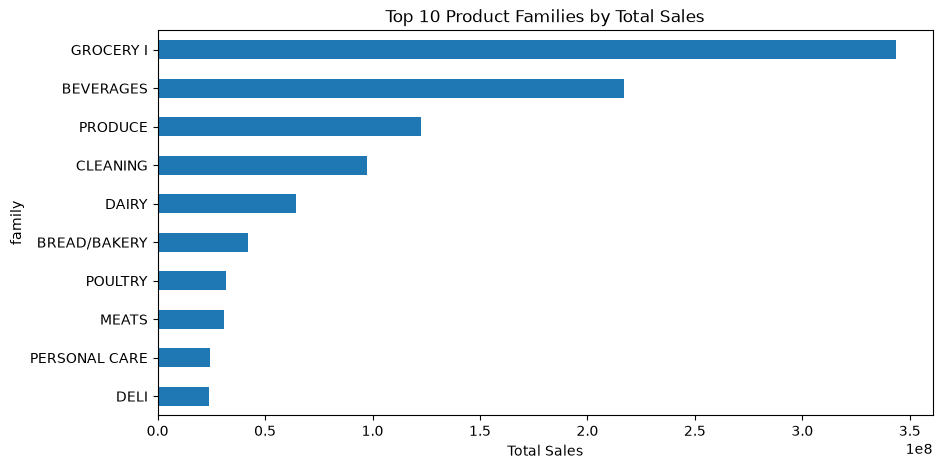

In [14]:
top_families = train.groupby('family')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_families.plot(kind='barh')
plt.title('Top 10 Product Families by Total Sales')
plt.xlabel('Total Sales')
plt.gca().invert_yaxis()
plt.savefig('top_families.png')
plt.show()

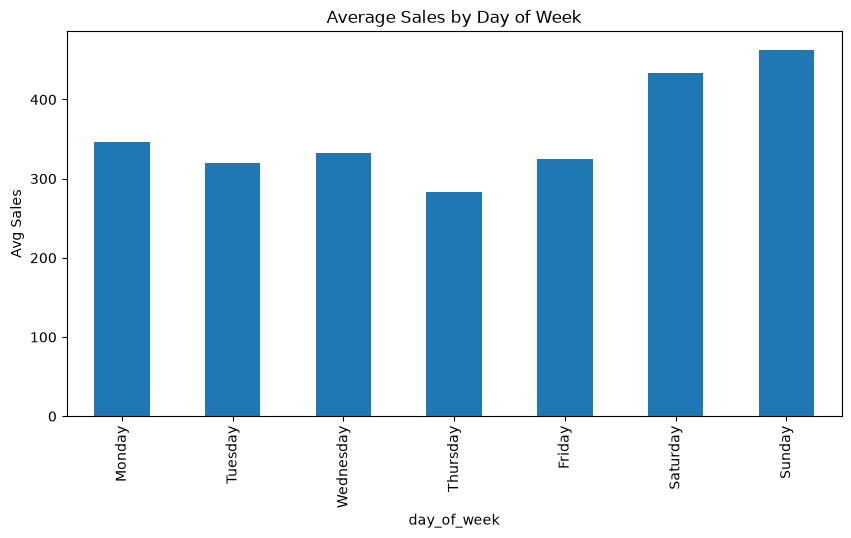

In [15]:
train['day_of_week'] = train['date'].dt.day_name()
dow_avg = train.groupby('day_of_week')['sales'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,5))
dow_avg.plot(kind='bar')
plt.title('Average Sales by Day of Week')
plt.ylabel('Avg Sales')
plt.savefig('day_of_week.png')
plt.show()

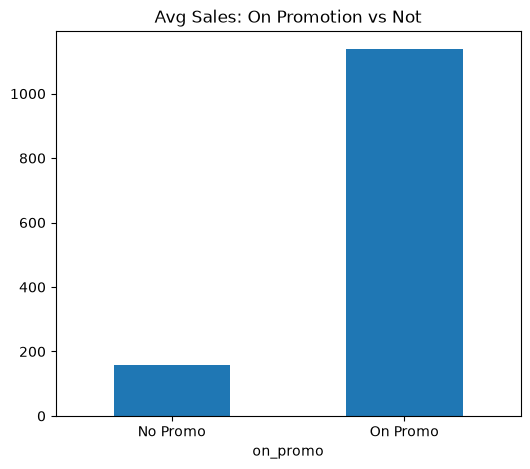

In [16]:
train['on_promo'] = (train['onpromotion'] > 0).astype(int)
promo_avg = train.groupby('on_promo')['sales'].mean()

plt.figure(figsize=(6,5))
promo_avg.plot(kind='bar')
plt.title('Avg Sales: On Promotion vs Not')
plt.xticks([0,1], ['No Promo','On Promo'], rotation=0)
plt.savefig('promo_impact.png')
plt.show()

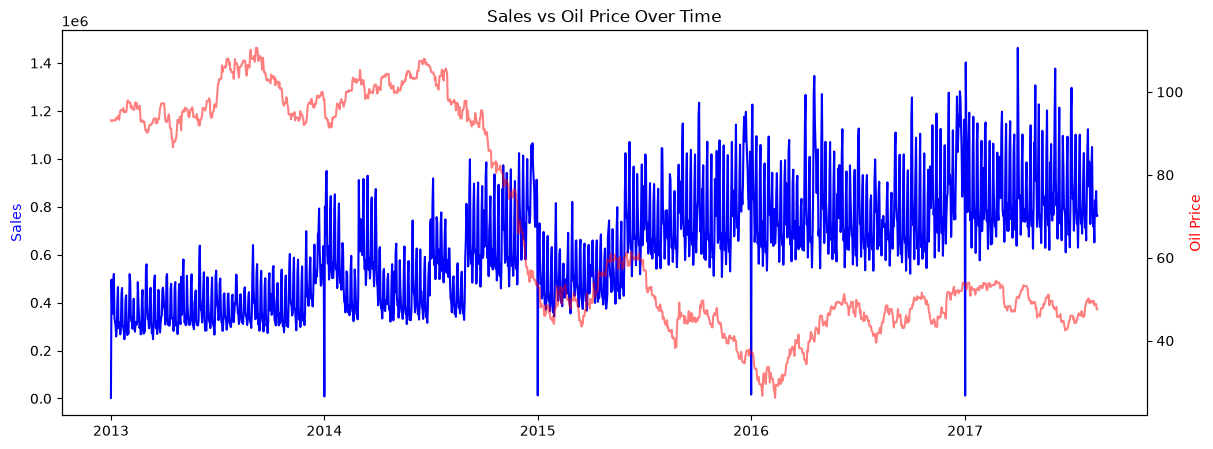

In [17]:
oil_sales_corr = train.groupby('date').agg({'sales':'sum','dcoilwtico':'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(14,5))
ax1.plot(oil_sales_corr['date'], oil_sales_corr['sales'], color='blue', label='Sales')
ax1.set_ylabel('Sales', color='blue')
ax2 = ax1.twinx()
ax2.plot(oil_sales_corr['date'], oil_sales_corr['dcoilwtico'], color='red', alpha=0.5, label='Oil Price')
ax2.set_ylabel('Oil Price', color='red')
plt.title('Sales vs Oil Price Over Time')
plt.savefig('oil_vs_sales.png')
plt.show()

In [18]:
train.to_csv('../data/cleaned_sales.csv', index=False)
print("Updated with new features!")

Updated with new features!
